Importing Libraries and load Dataset

In [60]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error , r2_score 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge , Lasso , ElasticNet , RidgeCV, LassoCV

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,4.5)
rng = np.random.default_rng(42)


• Generate your own noisy data from a known curve (a sine wave, or any curve you like) — the same style as the
notebook, so you know the true answer.

In [6]:
n_points = 30
x = np.sort(rng.uniform(0 , 1 , n_points))
y_true_curve = np.sin(2*np.pi*x)
y = y_true_curve + rng.normal(0,0.25,n_points)

x_grid = np.linspace(0,1,200)
y_grid_true = np.sin(2*np.pi*x_grid)

print(f"{n_points} noisy data points generated from a sine wave")

30 noisy data points generated from a sine wave


• Fit polynomial regression at degree 1, degree 5, and degree 15, and plot all three fits against the true curve on
one figure (or three side by side).

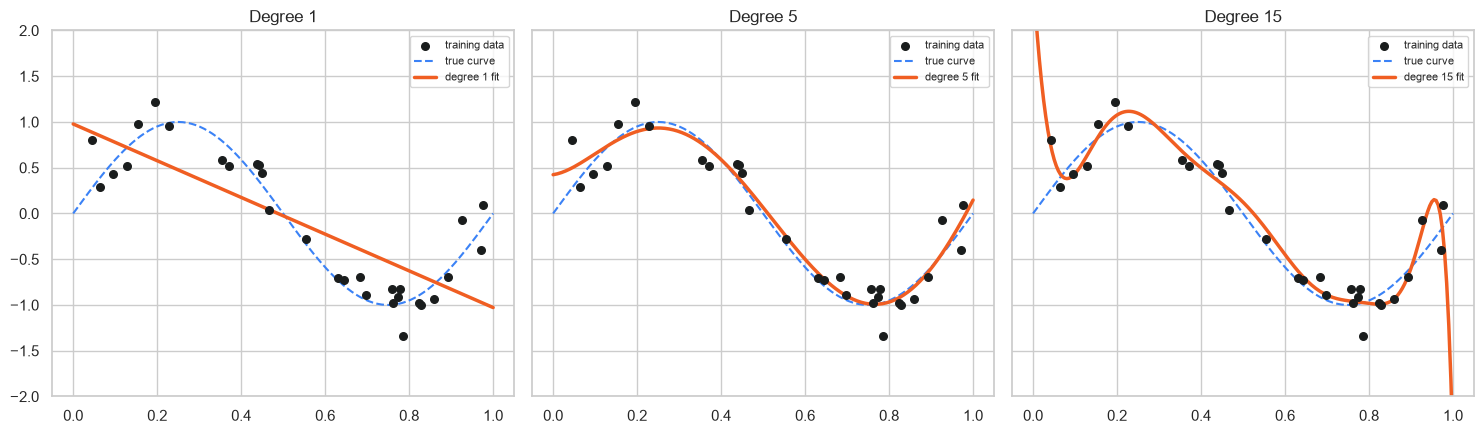

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)


for ax, degree in zip(axes, [1, 5, 15]):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(x.reshape(-1, 1))
    X_grid_poly = poly.transform(x_grid.reshape(-1, 1))

    model = LinearRegression().fit(X_poly, y)
    y_fit = model.predict(X_grid_poly)

    ax.scatter(x, y, color="#1A1D1D", s=30, zorder=3, label="training data")
    ax.plot(x_grid, y_grid_true, color="#3B82F6", linewidth=1.5, linestyle="--", label="true curve")
    ax.plot(x_grid, y_fit, color="#F05E22", linewidth=2.5, label=f"degree {degree} fit")
    ax.set_ylim(-2, 2)
    ax.set_title(f"Degree {degree}")
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

• For each degree, compute BOTH the training error and the error against the true underlying curve. Print both.

In [8]:
print("how well does each degree match the TRUE curve (not just the noisy training points)?")
for degree in [1, 5, 15]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(x.reshape(-1, 1))
    X_grid_poly = poly.transform(x_grid.reshape(-1, 1))
    model = LinearRegression().fit(X_poly, y)

    train_mse = mean_squared_error(y, model.predict(X_poly))
    true_curve_mse = mean_squared_error(y_grid_true, model.predict(X_grid_poly))
    print(f"  degree {degree:2}: training error = {train_mse:.4f},  error vs TRUE curve = {true_curve_mse:.4f}")

how well does each degree match the TRUE curve (not just the noisy training points)?
  degree  1: training error = 0.1978,  error vs TRUE curve = 0.2016
  degree  5: training error = 0.0349,  error vs TRUE curve = 0.0088
  degree 15: training error = 0.0238,  error vs TRUE curve = 0.1848


• Identify which degree underfits, which is close to right, and which overfits — and justify each label with the
numbers, not just the picture.

In [9]:
'''Degree 1 is underfit because its training error is high and gap between the best fit and data is high
degree 5 is close to right because it works good on testing data also 
degree 15 has lowest trainnig error but it learns the unnecessary noise also so on the tesing data it doesn`t work perfectly '''

'Degree 1 is underfit because its training error is high and gap between the best fit and data is high\ndegree 5 is close to right because it works good on testing data also \ndegree 15 has lowest trainnig error but it learns the unnecessary noise also so on the tesing data it doesn`t work perfectly '

TASK 02 The bias-variance curve

• Using a proper train/test split (not the true curve), compute train and test error across a range of polynomial
degrees (e.g. 1 through 15).

In [11]:
X_train , X_test , Y_train , Y_test = train_test_split(
    x.reshape(-1,1), y , test_size=0.2 , random_state=1)
degrees = [1,2,3,5,8,12,15]
train_error , test_error =[] , []

for degree in degrees :
    poly = PolynomialFeatures(degree=degree)
    Xtr_p = poly.fit_transform(X_train)
    Xte_p = poly.transform(X_test)
    model = LinearRegression().fit(Xtr_p,Y_train)
    train_error.append(mean_squared_error(Y_train , model.predict(Xtr_p)))
    test_error.append(mean_squared_error(Y_test , model.predict(Xte_p)))

print ("degree | train MSE | test MSE ")

for d , tr,te in zip (degrees,train_error,test_error):
    print(f"  {d:4}   |    {tr:.4f}   |   {te:.4f}")

degree | train MSE | test MSE 
     1   |    0.2009   |   0.2198
     2   |    0.1960   |   0.1974
     3   |    0.0452   |   0.0155
     5   |    0.0408   |   0.0142
     8   |    0.0260   |   0.0388
    12   |    0.0225   |   0.0157
    15   |    0.0260   |   0.0227


• Plot both error curves on one chart, degree on the x-axis.

• Identify the degree with the lowest TEST error — this is your bias-variance sweet spot.

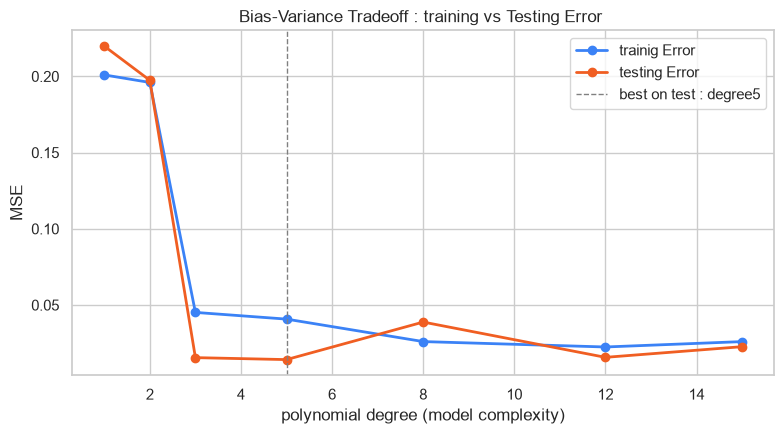

In [15]:
fig , ax = plt.subplots()
ax.plot(degrees, train_error , "o-", color ="#3B82F6", linewidth=2,label = "trainig Error")
ax.plot(degrees, test_error , "o-", color ="#F05E22", linewidth=2,label = "testing Error")
best_degree = degrees[np.argmin(test_error)]
ax.axvline(best_degree , color = "grey",linestyle = "--" , linewidth=1, label=f"best on test : degree{best_degree}")
ax.set_title("Bias-Variance Tradeoff : training vs Testing Error ")
ax.set_xlabel("polynomial degree (model complexity)"); ax.set_ylabel("MSE")
ax.legend(); plt.tight_layout(); plt.show()

• Write two sentences: what does the shape of each curve tell you about bias versus variance at low vs high
degree?

In [16]:
'''
Low Degree = High bias , low variance model id underfit
high Degree = low Bias High Variance model becomes too complex snd may overfit 
best degree : balance bias and variance , givivng good performance 

'''

'\nLow Degree = High bias , low variance model id underfit\nhigh Degree = low Bias High Variance model becomes too complex snd may overfit \nbest degree : balance bias and variance , givivng good performance \n\n'

TASK 03 Apply all three regularizers

• Load and scale the California housing features exactly as in the notebook (or reuse your Day 21 pipeline).

In [21]:
df = pd.read_csv("california_housing.csv")
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"].values
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"features: {feature_names}")
print(f"training on {len(X_train)}, testing on {len(X_test)} districts")

features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
training on 4000, testing on 1000 districts


• Fit plain Linear Regression, Ridge, Lasso, and Elastic Net, each at a couple of different strengths, and report
test R2 for all of them in one table.

• For Ridge and Lasso, report how many coefficients are EXACTLY zero at each strength.

• Write one sentence per model: what is each one actually doing differently to the coefficients?

In [62]:


models = {
    "Linear Regression": LinearRegression()
}

for alpha in np.logspace(-3, 1, 10):
    models[f"Ridge (alpha={alpha:.4f})"] = Ridge(alpha=alpha)
    models[f"Lasso (alpha={alpha:.4f})"] = Lasso(alpha=alpha, max_iter=10000)
    models[f"Elastic Net (alpha={alpha:.4f})"] = ElasticNet(
        alpha=alpha, l1_ratio=0.5, max_iter=10000
        )


results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Test prediction
    y_pred = model.predict(X_test)

    # Test R2
    test_r2 = r2_score(y_test, y_pred)

    # Count exactly-zero coefficients
    zero_coefficients = np.sum(model.coef_ == 0)

    results.append({
        "Model": name,
        "Test R2": test_r2,
        "Exact Zero Coefficients": zero_coefficients
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

print("\n Ridge: Shrinks all coefficients toward zero but usually does not make them exactly zero.")

print("\n Lasso: Shrinks coefficients and can make some exactly zero, effectively removing those features.")

print("\n Elastic Net: Combines Ridge and Lasso, shrinking coefficients while also allowing some to become exactly zero.")

                      Model  Test R2  Exact Zero Coefficients
          Linear Regression 0.838290                        0
       Ridge (alpha=0.0010) 0.838290                        0
       Lasso (alpha=0.0010) 0.838330                        1
 Elastic Net (alpha=0.0010) 0.838347                        1
       Ridge (alpha=0.0028) 0.838290                        0
       Lasso (alpha=0.0028) 0.838276                        1
 Elastic Net (alpha=0.0028) 0.838334                        1
       Ridge (alpha=0.0077) 0.838290                        0
       Lasso (alpha=0.0077) 0.838037                        1
 Elastic Net (alpha=0.0077) 0.838270                        1
       Ridge (alpha=0.0215) 0.838290                        0
       Lasso (alpha=0.0215) 0.836680                        1
 Elastic Net (alpha=0.0215) 0.837880                        1
       Ridge (alpha=0.0599) 0.838290                        0
       Lasso (alpha=0.0599) 0.829112                        2
 Elastic

TASK 04 Prove Lasso does feature selection

• Run Lasso across a range of alpha values from very small to fairly large.

• For each alpha, print which specific features have been zeroed out (by name, not just a count).

In [43]:
for alpha in np.logspace(-3, 0, 20):
    lasso = Lasso(alpha=alpha, max_iter=5000).fit(X_train , y_train)
    dropped = [f for f, c in zip(feature_names, lasso.coef_) if c == 0]
    remaining=[f for f , c in zip(feature_names, lasso.coef_) if c != 0]

    print(f"\n Alpha = {alpha:.4f}")
    print("Dropped features:", dropped)
    print("Remaining features:", remaining)


    if first_zero_alpha is None and len(dropped) > 0:
        first_zero_alpha = alpha
        first_zero_feature = dropped[0]

    # Only one feature remains
    if one_feature_alpha is None and len(remaining) == 1:
        one_feature_alpha = alpha
        surviving_feature = remaining[0]



 Alpha = 0.0010
Dropped features: ['AveBedrms']
Remaining features: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

 Alpha = 0.0014
Dropped features: ['AveBedrms']
Remaining features: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

 Alpha = 0.0021
Dropped features: ['AveBedrms']
Remaining features: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

 Alpha = 0.0030
Dropped features: ['AveBedrms']
Remaining features: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

 Alpha = 0.0043
Dropped features: ['AveBedrms']
Remaining features: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

 Alpha = 0.0062
Dropped features: ['AveBedrms']
Remaining features: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

 Alpha = 0.0089
Dropped features: ['AveBedrms']
Remaining features: [

• Identify the alpha at which the FIRST feature drops to zero, and which feature it is.

• Identify the alpha at which only one feature remains — which feature survives the longest, and why do you think
that is?

In [47]:
print("First Feature dropped AveBedrms ar alpha = 0.0010")

print("\n 'MedInc' , 'Population' , 'HouseAge'  => This features are remain ")

print("\n 'MedInc' is the longest surviceing feature")

First Feature dropped AveBedrms ar alpha = 0.0010

 'MedInc' , 'Population' , 'HouseAge'  => This features are remain 

 'MedInc' is the longest surviceing feature


TASK 05 Explain the L1 vs L2 geometry in your own words

• Reproduce the L1-diamond vs L2-circle constraint-region plot from the notebook (or adapt it).

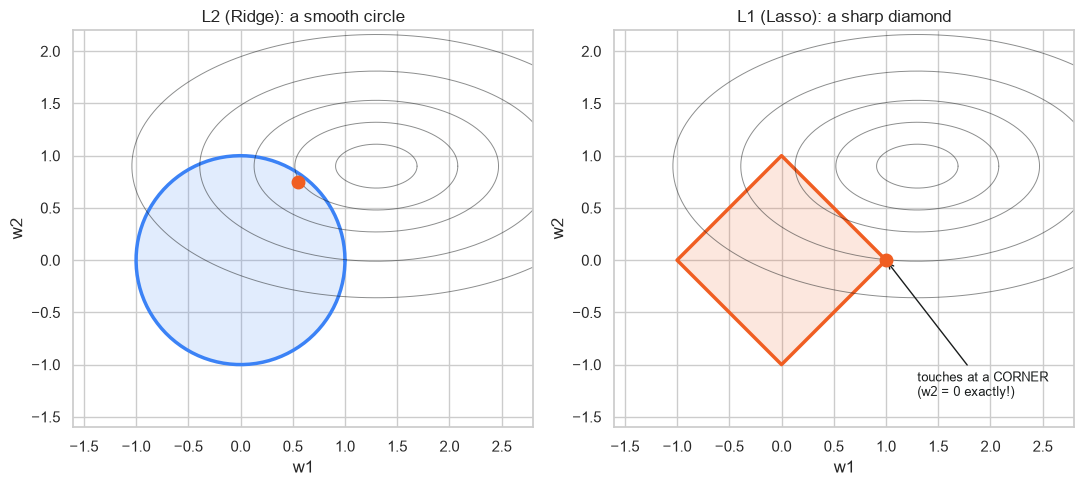

In [52]:
fig, axes = plt.subplots(1,2, figsize = (11,6))

theta = np.linspace(0,2*np.pi , 200)

ax = axes[0]
circle_x , circle_y = np.cos(theta),np.sin(theta)
ax.plot(circle_x, circle_y, color="#3B82F6", linewidth=2.5)
ax.fill(circle_x, circle_y, color="#3B82F6", alpha=0.15)

for r in [0.3,0.6,0.9,1.3,1.8]:
    ell_x = 1.3 + r*np.cos(theta)*1.3
    ell_y = 0.9 + r*np.sin(theta)*0.7
    ax.plot(ell_x, ell_y, color="#1A1D1D", linewidth=0.7, alpha=0.5)
ax.plot(0.55, 0.75, "o", color="#F05E22", markersize=9, zorder=5)
ax.set_title("L2 (Ridge): a smooth circle")
ax.set_xlim(-1.6, 2.8); ax.set_ylim(-1.6, 2.2); ax.set_aspect("equal")
ax.set_xlabel("w1"); ax.set_ylabel("w2")


ax = axes[1]
diamond_x = np.array([1, 0, -1, 0, 1])
diamond_y = np.array([0, 1, 0, -1, 0])
ax.plot(diamond_x, diamond_y, color="#F05E22", linewidth=2.5)
ax.fill(diamond_x, diamond_y, color="#F05E22", alpha=0.15)
for r in [0.3, 0.6, 0.9, 1.3, 1.8]:
    ell_x = 1.3 + r*np.cos(theta)*1.3
    ell_y = 0.9 + r*np.sin(theta)*0.7
    ax.plot(ell_x, ell_y, color="#1A1D1D", linewidth=0.7, alpha=0.5)
ax.plot(1.0, 0.0, "o", color="#F05E22", markersize=9, zorder=5)
ax.annotate("touches at a CORNER\n(w2 = 0 exactly!)", xy=(1.0, 0.0), xytext=(1.3, -1.3),
            fontsize=9, color="#1A1D1D", arrowprops=dict(arrowstyle="->", color="#1A1D1D"))
ax.set_title("L1 (Lasso): a sharp diamond")
ax.set_xlim(-1.6, 2.8); ax.set_ylim(-1.6, 2.2); ax.set_aspect("equal")
ax.set_xlabel("w1"); ax.set_ylabel("w2")

plt.tight_layout(); plt.show()

• In your own words (not copied from the notebook), write a paragraph explaining why the L1 diamond's corners
produce exact zeros while the L2 circle's smooth boundary does not.

L1 regularization has a diamond-shaped constraint with sharp corners, so during optimization the best solution can land exactly on an axis where one or more coefficients become zero. L2 regularization has a smooth circular boundary without sharp corners, so the solution is usually pulled toward zero but rarely reaches it exactly, meaning its coefficients generally remain small but non-zero.

Draw (by hand or in code) what the L1 shape looks like in 3 dimensions (three coefficients) — how many corners
does it have now?

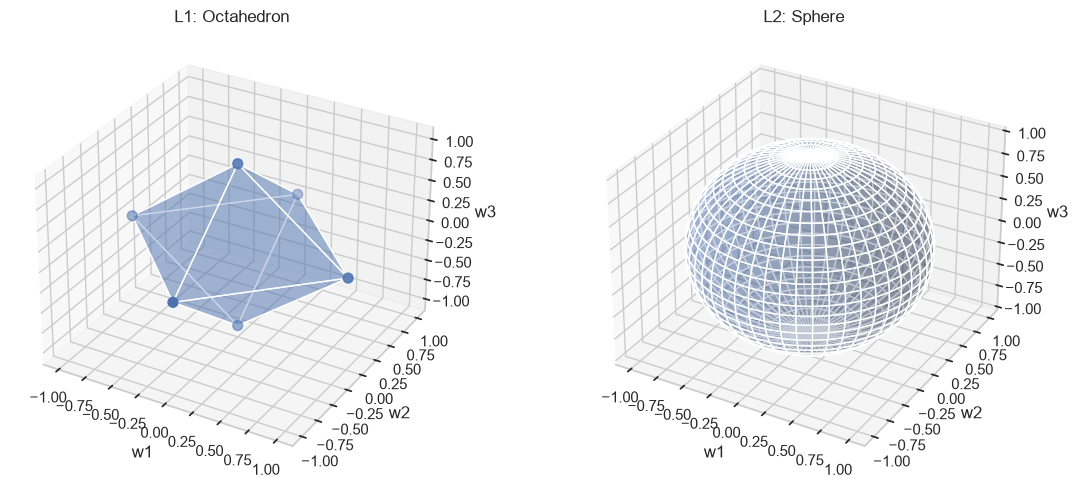

In [55]:

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(12, 5))

# ---------- L1: Octahedron ----------
ax1 = fig.add_subplot(121, projection="3d")

v = np.array([
    [1, 0, 0], [-1, 0, 0],
    [0, 1, 0], [0, -1, 0],
    [0, 0, 1], [0, 0, -1]
])

faces = [
    [0, 2, 4], [0, 4, 3],
    [0, 3, 5], [0, 5, 2],
    [1, 4, 2], [1, 3, 4],
    [1, 5, 3], [1, 2, 5]
]

ax1.add_collection3d(
    Poly3DCollection(
        [[v[i] for i in face] for face in faces],
        alpha=0.3
    )
)

ax1.scatter(v[:, 0], v[:, 1], v[:, 2], s=50)

ax1.set_title("L1: Octahedron")
ax1.set_xlabel("w1")
ax1.set_ylabel("w2")
ax1.set_zlabel("w3")

# ---------- L2: Sphere ----------
ax2 = fig.add_subplot(122, projection="3d")

u = np.linspace(0, 2 * np.pi, 50)
v_angle = np.linspace(0, np.pi, 30)

x = np.outer(np.cos(u), np.sin(v_angle))
y = np.outer(np.sin(u), np.sin(v_angle))
z = np.outer(np.ones_like(u), np.cos(v_angle))

ax2.plot_surface(x, y, z, alpha=0.3)

ax2.set_title("L2: Sphere")
ax2.set_xlabel("w1")
ax2.set_ylabel("w2")
ax2.set_zlabel("w3")

plt.tight_layout()
plt.show()

l1 has 6 
l2 has 0

TASK 06 Coefficient paths and honest tuning

• Plot the full coefficient path (coefficient value vs alpha) for both Ridge and Lasso on your California housing
features

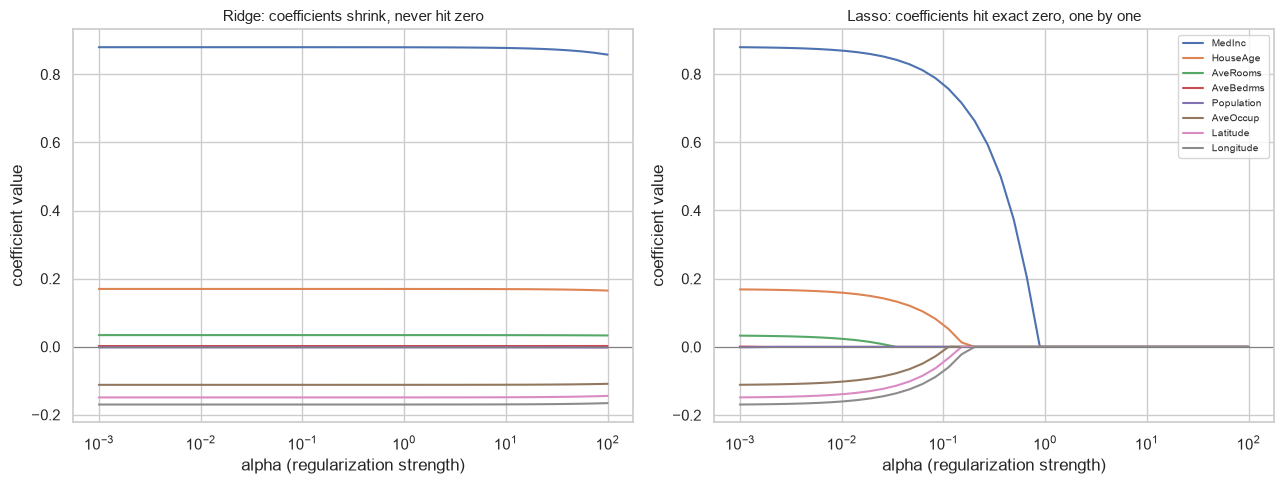

In [57]:
alphas = np.logspace(-3, 2, 40)
ridge_coef_path = np.array([Ridge(alpha=a).fit(X_train_s, y_train).coef_ for a in alphas])
lasso_coef_path = np.array([Lasso(alpha=a, max_iter=5000).fit(X_train_s, y_train).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, name in enumerate(feature_names):
    axes[0].plot(alphas, ridge_coef_path[:, i], label=name)
    axes[1].plot(alphas, lasso_coef_path[:, i], label=name)

for ax, title in zip(axes, ["Ridge: coefficients shrink, never hit zero", "Lasso: coefficients hit exact zero, one by one"]):
    ax.set_xscale("log")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_xlabel("alpha (regularization strength)"); ax.set_ylabel("coefficient value")
    ax.set_title(title, fontsize=10.5)

axes[1].legend(fontsize=7.5, loc="upper right")
plt.tight_layout(); plt.show()

• Use RidgeCV and LassoCV to automatically select the best alpha for each.

In [61]:
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_s, y_train)
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=5000).fit(X_train_s, y_train)

print(f"RidgeCV chose alpha = {ridge_cv.alpha_:.4f}")
print(f"  test R2: {r2_score(y_test, ridge_cv.predict(X_test_s)):.4f}")

print(f"\nLassoCV chose alpha = {lasso_cv.alpha_:.4f}")
print(f"  test R2: {r2_score(y_test, lasso_cv.predict(X_test_s)):.4f}")
print(f"  features kept: {(lasso_cv.coef_ != 0).sum()}/{len(lasso_cv.coef_)}")
print(f"  dropped: {[f for f, c in zip(feature_names, lasso_cv.coef_) if c == 0]}")

RidgeCV chose alpha = 3.5565
  test R2: 0.8384

LassoCV chose alpha = 0.0026
  test R2: 0.8385
  features kept: 6/8
  dropped: ['AveBedrms', 'Population']


• Compare the CV-selected alphas' test R2 against your best hand-picked alpha from Task 3 — how close are
they?

In [64]:
'''Best hand-picked:
RidgeCV: alpha = 3.5565 → Test R² = 0.8384
LassoCV: alpha = 0.0026 → Test R² = 0.8385
Conclusion:CV-selected models are very close and slightly better than the best hand-picked result.
'''

'Best hand-picked:\nRidgeCV: alpha = 3.5565 → Test R² = 0.8384\nLassoCV: alpha = 0.0026 → Test R² = 0.8385\nConclusion:CV-selected models are very close and slightly better than the best hand-picked result.\n'

• Write two sentences on why tuning via cross-validation on the TRAINING set is more trustworthy than tuning by
eye on the test set.

In [65]:
# Because it checks the multiple values for the model then finds out which one is the best for the model where the least error is there 
# by cross validation it validate all data into multiple parts 
